In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [5]:
# Load Fashion MNIST dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


In [7]:
# Flatten images (28x28 -> 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

In [8]:
# Autoencoder Architecture
input_img = Input(shape=(784,))

In [9]:
# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)

In [10]:
# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)


In [11]:
# Autoencoder Model
autoencoder = Model(input_img, decoded)

In [12]:
# Compile model
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

In [13]:
# Train for 5 epochs
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.3668 - val_loss: 0.3113
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3020 - val_loss: 0.2994
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2943 - val_loss: 0.2937
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2895 - val_loss: 0.2900
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2863 - val_loss: 0.2869


In [14]:
# Reconstruct test images
reconstructed = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [15]:
# Display Original and Reconstructed Image
n = 0  # first image

plt.figure(figsize=(6,3))


<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

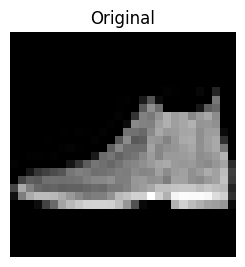

In [16]:
# Original Image
plt.subplot(1,2,1)
plt.imshow(x_test[n].reshape(28,28), cmap='gray')
plt.title("Original")
plt.axis('off')


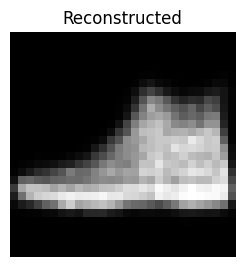

In [17]:
# Reconstructed Image
plt.subplot(1,2,2)
plt.imshow(reconstructed[n].reshape(28,28), cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()